In [1]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import sys
import pickle5 as pickle 

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pypsa
import pandas as pd
import statsmodels.api as sm
from tqdm import tqdm
from sklearn.utils import resample
import seaborn as sns

path = '/media/fkaiser/'

sys.path.append('../power_system_split/')
import utils,visualisation

# Evaluate component cluster for single CO$_2$ level (not finalized)

In [3]:
co2l = 0.5
path_to_pypsa_network   = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/'
results_path = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/Results/'

network = pypsa.Network()
network.import_from_netcdf(path_to_pypsa_network+'elec_s_800_ec_lv1.0_Co2L%.1f-3H.nc'%co2l) # +year+'/elec_s_306_ec_lv1.0_1H.nc')#

criterion = 'nodes' # or 'load'
snet_index = 0
G = utils.build_networkx_graph(network, snet_index = snet_index)

splitting_cascades = pickle.load(open(results_path+'system_splits_Co2L%.1f.pickle' % (co2l),'rb'))
solution_dict = pickle.load(open(results_path+'Europe_Co2L%.1f_split_evaluation_'%co2l+criterion+'_based_snet_%i'%snet_index+'.pickle','rb'))


/media/jkruse/Projects/system_splits/power-system-split/venv/lib/python3.7/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/media/jkruse/Projects/system_splits/power-system-split/venv/lib/python3.7/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.5-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


In [4]:
total_number_of_components = 0

for time_stamp in solution_dict.keys():
    if not solution_dict[time_stamp]:
        continue
    for i, split_number in enumerate(solution_dict[time_stamp][::2]):
        component_props = solution_dict[time_stamp][i*2+1]
        total_number_of_components += len(component_props['inertia_proxy'])
        
print(total_number_of_components)
print(len(solution_dict.keys()))

32092
2920


In [53]:
n_subset_solutions = -1

if n_subset_solutions==-1:
    indicator_vectors, component_props = visualisation.indicator_vectors_from_rocof_solution(solution_dict, splitting_cascades, G, criterion=criterion)
else:
    subset_of_keys = np.random.choice(list(solution_dict.keys()), n_subset_solutions, replace=False)
    subset_solution_dict = {key: solution_dict[key] for key in subset_of_keys}
    indicator_vectors, component_props = visualisation.indicator_vectors_from_rocof_solution(subset_solution_dict, splitting_cascades, G, criterion=criterion)

100%|██████████| 2920/2920 [07:38<00:00,  6.37it/s]


In [54]:
min_cluster_distance = 19./ len(G.nodes()) # if too large, than small components with ~10 nodes get joined into one cluster although they are far apart. Should we choose a distance metric that accounts for size of cluster, i.e. dist = hamming_dist / number_of_nodes
n_cluster, cluster_labels = visualisation.cluster_indicator_vectors(indicator_vectors, min_cluster_distance=min_cluster_distance)
component_props.loc[:, 'cluster_label'] = cluster_labels
n_cluster

69

In [55]:
bridges = list(nx.bridges(nx.Graph(G)))
non_bridges = list(set(list(G.edges())) - set(bridges))

if n_subset_solutions==-1:
    number_of_simulations = len(non_bridges)*len(solution_dict.keys())
else:
    number_of_simulations = len(non_bridges)*len(subset_solution_dict.keys())

component_props.loc[:,'rocof'] = component_props.load_imbalance / component_props.inertia_proxy
component_props.loc[:, 'number_of_nodes'] = indicator_vectors.sum(1)

cluster_props = component_props.groupby('cluster_label').size().to_frame('counts')
cluster_props.loc[:,'likelihood'] = cluster_props.counts.div(number_of_simulations)

cluster_props.loc[:,'mean_number_of_nodes'] = component_props.groupby('cluster_label')['number_of_nodes'].mean()

cluster_props.loc[:,'number_pos_inf_rocofs'] = component_props.groupby('cluster_label').apply(lambda x: np.isposinf(x.rocof).sum())
cluster_props.loc[:,'number_neg_inf_rocofs'] = component_props.groupby('cluster_label').apply(lambda x: np.isneginf(x.rocof).sum())

component_props.loc[:,'rocof'] = component_props.loc[:,'rocof'].replace([np.inf, -np.inf], np.nan).dropna()
cluster_props.loc[:,'median_pos_rocof'] = component_props[component_props.rocof>0].groupby('cluster_label')['rocof'].median()
cluster_props.loc[:,'mean_pos_rocof'] = component_props[component_props.rocof>0].groupby('cluster_label')['rocof'].mean()
cluster_props.loc[:,'min_pos_rocof'] = component_props[component_props.rocof>0].groupby('cluster_label')['rocof'].quantile(0.05) #.min()
cluster_props.loc[:,'max_pos_rocof'] = component_props[component_props.rocof>0].groupby('cluster_label')['rocof'].quantile(0.95) #.max()
cluster_props.loc[:,'median_neg_rocof'] = component_props[component_props.rocof<=0].groupby('cluster_label')['rocof'].median().abs()
cluster_props.loc[:,'mean_neg_rocof'] = component_props[component_props.rocof<=0].groupby('cluster_label')['rocof'].mean().abs()
cluster_props.loc[:,'max_neg_rocof'] = component_props[component_props.rocof<=0].groupby('cluster_label')['rocof'].quantile(0.05).abs() #min()
cluster_props.loc[:,'min_neg_rocof'] = component_props[component_props.rocof<=0].groupby('cluster_label')['rocof'].quantile(0.95).abs() #max()

cluster_props

,counts,likelihood,mean_number_of_nodes,number_pos_inf_rocofs,number_neg_inf_rocofs,median_pos_rocof,mean_pos_rocof,min_pos_rocof,max_pos_rocof,median_neg_rocof,mean_neg_rocof,max_neg_rocof,min_neg_rocof
cluster_label,,,,,,,,,,,,,
0,548,1.963088e-04,61.580292,0,0,0.212201,0.243220,0.091386,0.439296,0.145681,0.136352,0.230975,0.024729
1,4143,1.484138e-03,535.718320,0,0,0.017499,0.021920,0.001241,0.057433,0.032224,0.033718,0.065330,0.006551
2,550,1.970253e-04,544.380000,0,0,0.015935,0.021031,0.001157,0.061581,0.051133,0.053758,0.102171,0.017615
3,82,2.937468e-05,534.524390,0,0,0.046027,0.047597,0.023013,0.082678,0.068263,0.068263,0.068263,0.068263
4,1825,6.537657e-04,16.635616,1268,17,2.007023,3.505370,0.433137,8.486503,0.964874,1.186494,2.232317,0.323207
...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,1008,3.610936e-04,11.000000,0,0,15.464653,17.335468,11.339005,38.850856,10.453257,8.129657,15.963133,0.838759
65,1,3.582278e-07,88.000000,0,0,0.467174,0.467174,0.467174,0.467174,NaN,NaN,NaN,NaN
66,55,1.970253e-05,60.781818,0,0,0.238774,0.242845,0.179635,0.297590,NaN,NaN,NaN,NaN


In [65]:
# Interval for rejecting the null hypothesis that cluster label occurence is below p
p= 0.0001
min_count, max_counts = sm.stats.binom_test_reject_interval(p,number_of_simulations, alternative='larger', alpha=0.05)
print(max_counts)

selected_cluster = cluster_props.index[cluster_props.counts>max_counts]
n_selected_cluster = selected_cluster.size
print(selected_cluster)
print(n_selected_cluster)

308.0
Int64Index([0, 1, 2, 4, 6, 7, 8, 10, 12, 19, 20, 38, 44, 54, 60, 64], dtype='int64', name='cluster_label')
16


In [ ]:
# bootstrap confidence intervals for likelihood of cluster (under sampling from components)
# would have to be adapted to sampling from time stamps to be more consistent

#n_iterations = 1000
#n_samples = component_props.shape[0]
#
#stats = pd.DataFrame(index=range(n_iterations), columns=range(n_cluster))
#for i in range(n_iterations):
#    cluster_label_sample = resample(component_props.loc[:,['cluster_label']], n_samples=n_samples)
#    counts_in_sample = cluster_label_sample.groupby('cluster_label').size().reindex(range(n_cluster), fill_value=0)
#    stats.loc[i] = counts_in_sample.values
#
#for i in range(n_cluster):
#    #plt.hist(stats.iloc[:,i])
#    #plt.show()
#    alpha = 0.95
#    p = ((1.0-alpha)/2.0) * 100
#    lower =  np.percentile(stats.iloc[:,i], p)
#    p = (alpha+((1.0-alpha)/2.0)) * 100
#    upper =  np.percentile(stats.iloc[:,i], p)
#    print('%.1f confidence interval for likelihood of cluster %d: %.4f%% to %.4f%%' % (alpha*100,i, 100*lower/number_of_simulations, 100*upper/#number_of_simulations))

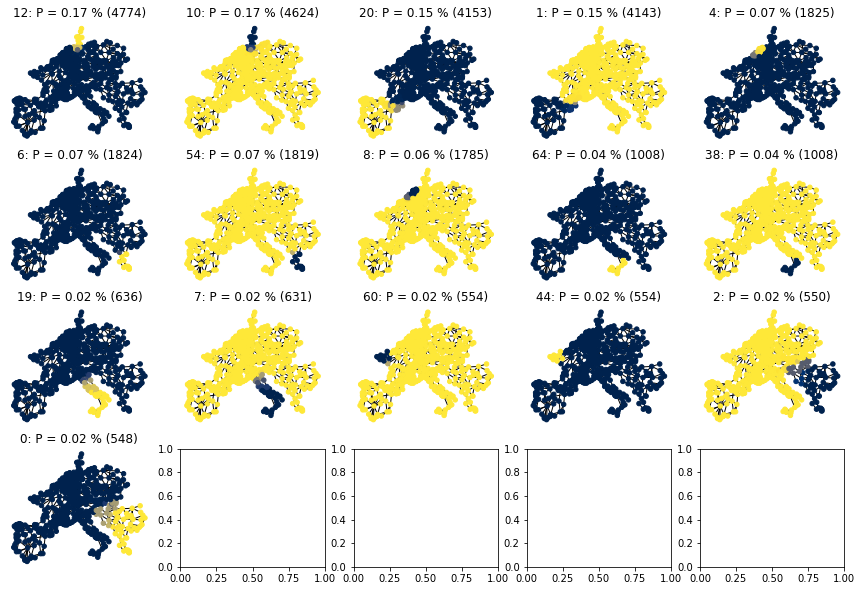

In [58]:
n_cols = 5
n_rows = np.ceil(n_selected_cluster/n_cols).astype(int)
fig,ax = plt.subplots(n_rows,n_cols,figsize=(15,10))

selected_cluster_props = cluster_props.loc[selected_cluster, ['likelihood', 'counts']] 
selected_cluster_labels = component_props[component_props.cluster_label.isin(selected_cluster)].cluster_label
selected_ind_vectors = indicator_vectors[component_props.cluster_label.isin(selected_cluster)]

visualisation.plot_component_cluster(selected_ind_vectors,
                                     ax.flatten()[:n_selected_cluster],
                                     selected_cluster_labels,
                                     selected_cluster_props,
                                     G)

Text(0, 0.5, 'RoCoF [Hz/s]')

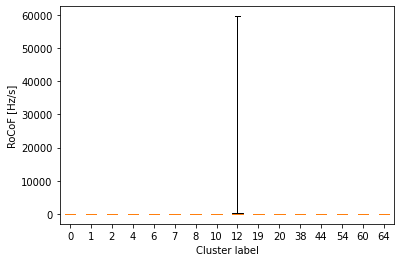

In [59]:
_= plt.boxplot(component_props[component_props.cluster_label.isin(selected_cluster)].dropna().groupby('cluster_label')['rocof'].apply(list).values,
               positions=range(selected_cluster.shape[0]),
               showfliers=False,
               whis=[10,90])
plt.gca().set_xticklabels(selected_cluster)
plt.xlabel('Cluster label')
plt.ylabel('RoCoF [Hz/s]')

<AxesSubplot:xlabel='cluster_label'>

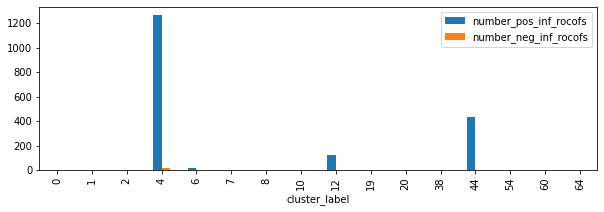

In [60]:
cluster_props.loc[selected_cluster,['number_pos_inf_rocofs', 'number_neg_inf_rocofs']].plot.bar(figsize=(10,3))

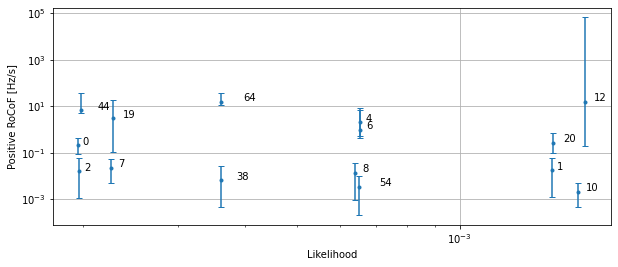

In [61]:
risks = cluster_props.loc[selected_cluster].median_pos_rocof
risk_ranges = (cluster_props.loc[selected_cluster,['min_pos_rocof', 'max_pos_rocof']].T -cluster_props.loc[selected_cluster].median_pos_rocof.values).abs()

likelihoods = cluster_props.loc[selected_cluster].likelihood

plt.figure(figsize=(10,4))
#colors = ['C{}'.format(i) for i in range(n_cluster)]
plt.errorbar(likelihoods.values, risks.values, yerr=risk_ranges.values, fmt='.', capsize=3)
for i in selected_cluster.values:
    plt.annotate('{}'.format(i), (likelihoods.loc[i]*1.02*(1+0.02*i/selected_cluster.size),risks.loc[i]*1.05), fontsize=10)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Likelihood')
plt.ylabel('Positive RoCoF [Hz/s]')
plt.grid()


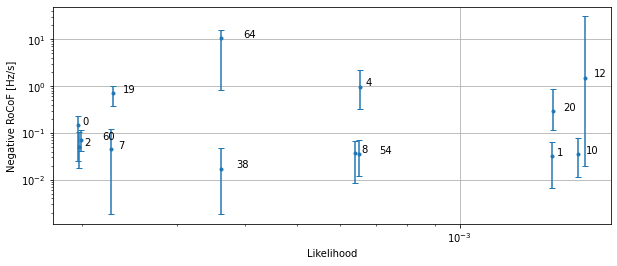

In [62]:
risks = cluster_props.loc[selected_cluster].median_neg_rocof
risk_ranges = (cluster_props.loc[selected_cluster,['min_neg_rocof', 'max_neg_rocof']].T -cluster_props.loc[selected_cluster].median_neg_rocof.values).abs()

likelihoods = cluster_props.loc[selected_cluster].likelihood

plt.figure(figsize=(10,4))
#colors = ['C{}'.format(i) for i in range(n_cluster)]
plt.errorbar(likelihoods.values, risks.values, yerr=risk_ranges.values, fmt='.', capsize=3)
for i in selected_cluster.values:
    plt.annotate('{}'.format(i), (likelihoods.loc[i]*1.02*(1+0.02*i/selected_cluster.size),risks.loc[i]*1.05), fontsize=10)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Likelihood')
plt.ylabel('Risk')
plt.ylabel('Negative RoCoF [Hz/s]')
plt.grid()

# Evaluate component cluster for CO$_2$ levels together

## Setup and load graph

In [13]:
path_to_pypsa_network   = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/'
results_path = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/Results/'
cluster_results_path = '/media/jkruse/Projects/system_splits/power-system-split/results/'

criterion = 'nodes' # or 'load'
snet_index = 0 # only AC grid of CE
co2l_list = [0.1, 0.2, 0.3, 0.4, 0.5]

n_subset_solutions = -1 # number of random sampled time steps from each co2 level simulation, -1 means all

In [14]:
# the graph G should be independent of co2l right? so that we can load it out of the loop!?
network = pypsa.Network()
network.import_from_netcdf(path_to_pypsa_network+'elec_s_800_ec_lv1.0_Co2L0.5-3H.nc') # +year+'/elec_s_306_ec_lv1.0_1H.nc')#
G = utils.build_networkx_graph(network, snet_index = snet_index)


/media/jkruse/Projects/system_splits/power-system-split/venv/lib/python3.7/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/media/jkruse/Projects/system_splits/power-system-split/venv/lib/python3.7/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.5-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


In [21]:
bridges = list(nx.bridges(nx.Graph(G)))
non_bridges = list(set(list(G.edges())) - set(bridges))
n_initial_failures = len(non_bridges)

if n_subset_solutions==-1:
    n_time_stamps = network.snapshots.size
else:
    n_time_stamps = n_subset_solutions

number_of_simulations = n_initial_failures*n_time_stamps

## Indicator vector construction 
Construct one data set of split components from all CO$_2$ level simulations

In [101]:

component_props = pd.DataFrame(columns= ['co2l','time_stamp', 'number_of_split', 'inertia_proxy', 'load_imbalance', 'available_flexible_generation'])
indicator_vectors = np.empty((0, len(G)))

for co2l in co2l_list:
    print('\n','CO2 level ', co2l)

    splitting_cascades = pickle.load(open(results_path+'system_splits_Co2L%.1f.pickle' % (co2l),'rb'))
    solution_dict = pickle.load(open(results_path+'Europe_Co2L%.1f_split_evaluation_'%co2l+criterion+'_based_snet_%i'%snet_index+'.pickle','rb'))
   
    if n_subset_solutions==-1:
        indicator_vectors_level, component_props_level = visualisation.indicator_vectors_from_rocof_solution(solution_dict,
                                                                                                             splitting_cascades,
                                                                                                             G, criterion=criterion)
    else:
        subset_of_keys = np.random.choice(list(solution_dict.keys()), n_subset_solutions, replace=False)
        subset_solution_dict = {key: solution_dict[key] for key in subset_of_keys}
        indicator_vectors_level, component_props_level = visualisation.indicator_vectors_from_rocof_solution(subset_solution_dict,
                                                                                                             splitting_cascades,
                                                                                                             G, criterion=criterion)
    indicator_vectors = np.concatenate([indicator_vectors, indicator_vectors_level])
    component_props_level.loc[:, 'co2l'] = co2l
    component_props = component_props.append(component_props_level, ignore_index=True)
    


/media/jkruse/Projects/system_splits/power-system-split/venv/lib/python3.7/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/media/jkruse/Projects/system_splits/power-system-split/venv/lib/python3.7/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.5-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units

 CO2 level  0.1
100%|██████████| 2920/2920 [09:48<00:00,  4.96it/s]

 CO2 level  0.2
100%|██████████| 2920/2920 [09:37<00:00,  5.06it

## Cluster split components 

In [102]:
#...this can take a few hours for all time steps and co2 levels
min_cluster_distance = 19./ len(G) 
n_cluster, cluster_labels = visualisation.cluster_indicator_vectors(indicator_vectors, min_cluster_distance=min_cluster_distance)
component_props.loc[:, 'cluster_label'] = cluster_labels
n_cluster

159

In [115]:
#np.save(cluster_results_path + 'indicator_vectors_all_co2level_{}_based.npy'.format(criterion), indicator_vectors )
#component_props.to_hdf(cluster_results_path + 'split_component_properties_all_co2level_{}_based.h5'.format(criterion), key='df')

## Load clustering results

In [9]:
indicator_vectors = np.load(cluster_results_path + 'indicator_vectors_all_co2level_{}_based.npy'.format(criterion))
component_props = pd.read_hdf(cluster_results_path + 'split_component_properties_all_co2level_{}_based.h5'.format(criterion))

## Add component and cluster properties 

In [22]:
# Add component properties
component_props.loc[:,'rocof'] = component_props.load_imbalance / component_props.inertia_proxy
component_props.loc[:, 'number_of_nodes'] = indicator_vectors.sum(1)

# Construct cluster properties and add likelihood of cluster given a certain co2 level
# (Likelihood = Prob. that split of this cluster occurs at random time and initial failure)
cluster_props = component_props.groupby(['cluster_label','co2l']).size().to_frame('counts')
cluster_props.loc[:,'likelihood'] = cluster_props.counts.div(number_of_simulations)
cluster_props.loc[:,'mean_number_of_nodes'] = component_props.groupby(['cluster_label','co2l'])['number_of_nodes'].mean()

# Count infinity rocofs and then set them no nan in component properties
cluster_props.loc[:,'number_pos_inf_rocofs'] = component_props.groupby(['cluster_label','co2l']).apply(lambda x: np.isposinf(x.rocof).sum())
cluster_props.loc[:,'number_neg_inf_rocofs'] = component_props.groupby(['cluster_label','co2l']).apply(lambda x: np.isneginf(x.rocof).sum())
component_props.loc[:,'rocof'] = component_props.loc[:,'rocof'].replace([np.inf, -np.inf], np.nan).dropna()


# Calculate rocof statistics for each cluster given a certain co2 level
cluster_props.loc[:,'median_rocof'] = component_props.groupby(['cluster_label','co2l'])['rocof'].median()
cluster_props.loc[:,'median_pos_rocof'] = component_props[component_props.rocof>0].groupby(['cluster_label','co2l'])['rocof'].median()
cluster_props.loc[:,'mean_pos_rocof'] = component_props[component_props.rocof>0].groupby(['cluster_label','co2l'])['rocof'].mean()
cluster_props.loc[:,'min_pos_rocof'] = component_props[component_props.rocof>0].groupby(['cluster_label','co2l'])['rocof'].quantile(0.05) #.min()
cluster_props.loc[:,'max_pos_rocof'] = component_props[component_props.rocof>0].groupby(['cluster_label','co2l'])['rocof'].quantile(0.95) #.max()
cluster_props.loc[:,'median_neg_rocof'] = component_props[component_props.rocof<=0].groupby(['cluster_label','co2l'])['rocof'].median().abs()
cluster_props.loc[:,'mean_neg_rocof'] = component_props[component_props.rocof<=0].groupby(['cluster_label','co2l'])['rocof'].mean().abs()
cluster_props.loc[:,'max_neg_rocof'] = component_props[component_props.rocof<=0].groupby(['cluster_label','co2l'])['rocof'].quantile(0.05).abs() #min()
cluster_props.loc[:,'min_neg_rocof'] = component_props[component_props.rocof<=0].groupby(['cluster_label','co2l'])['rocof'].quantile(0.95).abs() #max()

# convert rocof to absolute rocof and save sign
component_props.loc[:,'rocof_positive'] = component_props.loc[:,'rocof']>0
component_props.loc[:,'rocof'] = component_props.loc[:,'rocof'].abs()

# this DataFrame has a Multiindex (cluster_label, co2l)
cluster_props.head()

counts  likelihood  mean_number_of_nodes  \
cluster_label co2l                                             
0             0.1      108    0.000039             66.166667   
              0.2       74    0.000027             62.932432   
              0.3       55    0.000020             65.054545   
              0.4       66    0.000024             68.500000   
              0.5       82    0.000029             67.365854   

                    number_pos_inf_rocofs  number_neg_inf_rocofs  \
cluster_label co2l                                                 
0             0.1                       0                      0   
              0.2                       0                      0   
              0.3                       0                      0   
              0.4                       0                      0   
              0.5                       0                      0   

                    median_rocof  median_pos_rocof  mean_pos_rocof  \
cluster_label co2l                                                   
0             0.1      -0.444324          3.230855        2.828875   
              0.2       0.277133          0.923397        1.702087   
              0.3      -0.382615          1.550985        2.019733   
              0.4      -0.598134               NaN             NaN   
              0.5      -0.531610          0.884389        0.884389   

                    min_pos_rocof  max_pos_rocof  median_neg_rocof  \
cluster_label co2l                                                   
0             0.1        0.488747       4.392933          0.556438   
              0.2        0.272569       6.181536          0.409925   
              0.3        0.292389       4.906803          0.499538   
              0.4             NaN            NaN          0.598134   
              0.5        0.884389       0.884389          0.536975   

                    mean_neg_rocof  max_neg_rocof  min_neg_rocof  
cluster_label co2l                                                
0             0.1         0.686246       1.562248       0.254857  
              0.2         0.576966       1.472769       0.240557  
              0.3         0.646137       1.322728       0.277053  
              0.4         0.583417       0.791953       0.276487  
              0.5         0.526041       0.763697       0.267283

## Select a few cluster for analysis

In [23]:
# Only select cluster if there is at least one co2l with P(cluster | co2l) significantly larger than p (alpha=0.05)
# (i.e. we omit very unlikely clusters)
p= 0.00076
min_count, max_counts = sm.stats.binom_test_reject_interval(p,number_of_simulations, alternative='larger', alpha=0.05)
print('Rejected if not more than', int(max_counts), 'hits in all', number_of_simulations, 'simulations')

#selected_cluster = cluster_props.index[cluster_props.counts>max_counts]
#n_selected_cluster = selected_cluster.get_level_values('cluster_label').unique().size

selected_cluster_mask = cluster_props.groupby('cluster_label').apply(lambda x: (x.counts>max_counts).any())
selected_cluster = selected_cluster_mask[selected_cluster_mask].index
n_selected_cluster = selected_cluster.size

print('Labels of selected cluster:', selected_cluster)
print('Number of selected cluster:', n_selected_cluster)

Rejected if not more than 2199 hits in all 2791520 simulations
Labels of selected cluster: Int64Index([4, 6, 12, 15, 28, 60, 77, 103], dtype='int64', name='cluster_label')
Number of selected cluster: 8


## Plot cluster on map

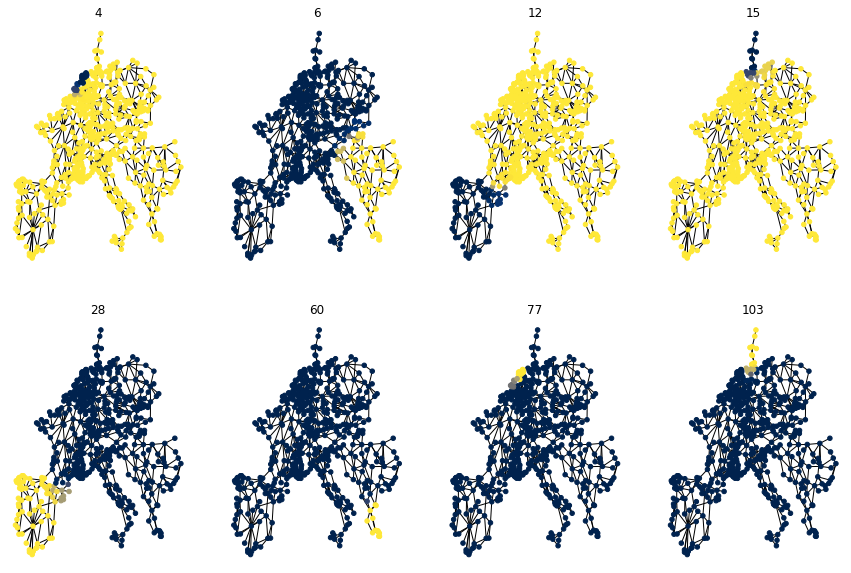

In [171]:
# Plot mean component vector of selected (cluster, co2l) samples
# (Does this make sense to only average over selected tuples?)

n_cols = 4 # adapt this value!

n_rows = np.ceil(n_selected_cluster/n_cols).astype(int)
fig,ax = plt.subplots(n_rows,n_cols,figsize=(15,10))

#selected_components_mask = pd.MultiIndex.from_frame(component_props.loc[:,['cluster_label', 'co2l']]).isin(selected_cluster)
#selected_cluster_labels = component_props[selected_components_mask].cluster_label
#selected_ind_vectors = indicator_vectors[selected_components_mask]

selected_ind_vectors = indicator_vectors[component_props.cluster_label.isin(selected_cluster)]
selected_cluster_labels = component_props[component_props.cluster_label.isin(selected_cluster)].cluster_label

visualisation.plot_component_cluster(selected_ind_vectors,
                                     ax.flatten()[:n_selected_cluster],
                                     selected_cluster_labels.values,
                                     None,
                                     G)

## Infinite Rocofs

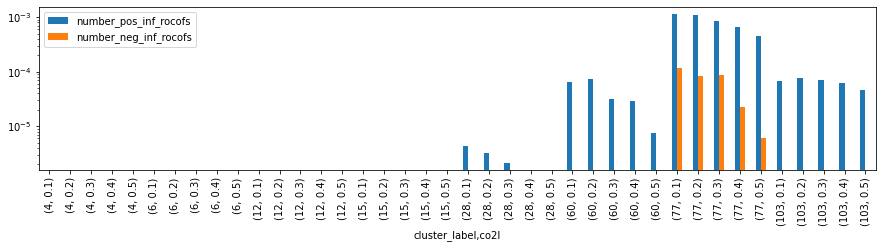

In [172]:
# Display number of infinite rocofs
cluster_props.loc[selected_cluster,['number_pos_inf_rocofs', 'number_neg_inf_rocofs']].div(number_of_simulations).plot.bar(figsize=(15,3))
plt.yscale('log')

## Dependence on CO$_2$ level

In [29]:
#selected_components_mask = pd.MultiIndex.from_frame(component_props.loc[:,['cluster_label', 'co2l']]).isin(selected_cluster)
#selected_components = component_props[selected_components_mask]

selected_components = component_props[component_props.cluster_label.isin(selected_cluster)]

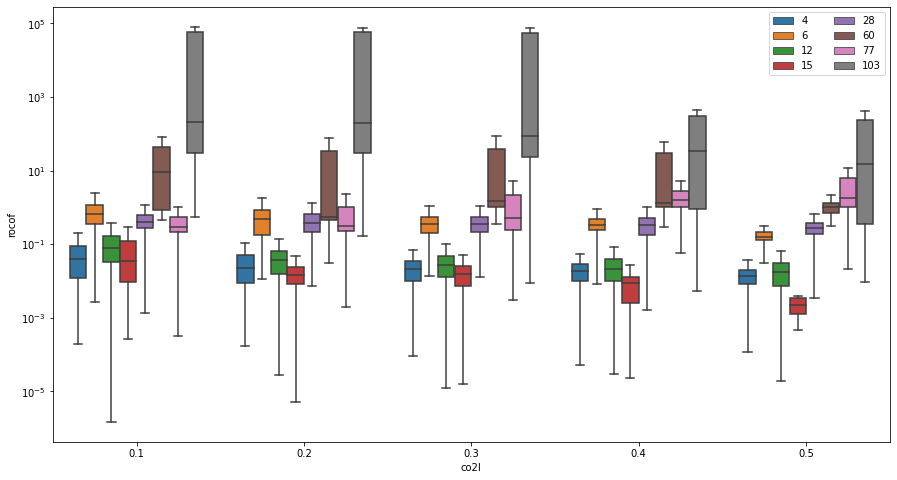

In [30]:
plt.figure(figsize=(15,8))
sns.boxplot(data=selected_components[selected_components.rocof_positive], x='co2l', y='rocof', hue='cluster_label', showfliers=False)
plt.legend(ncol=2)
#plt.xlim([-0.5,6])
plt.yscale('log')

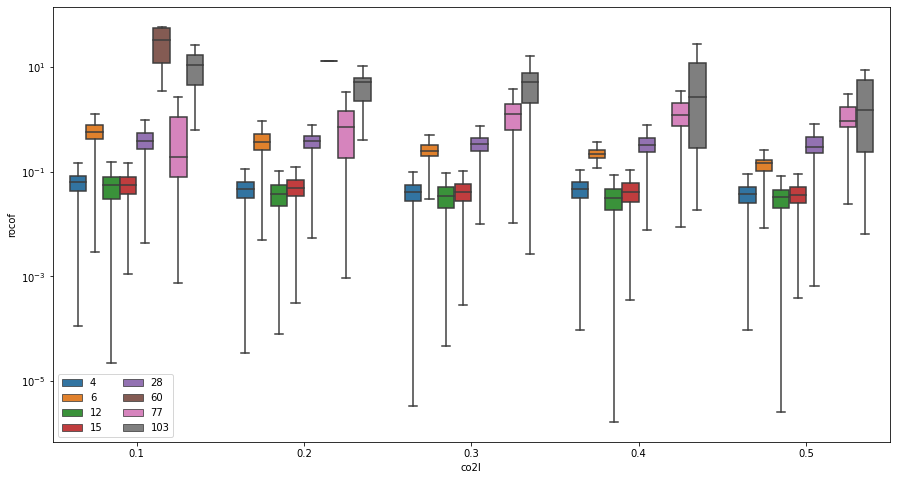

In [31]:
plt.figure(figsize=(15,8))
sns.boxplot(data=selected_components[~selected_components.rocof_positive], x='co2l', y='rocof', hue='cluster_label', showfliers=False)
plt.legend(ncol=2)
#plt.xlim([-0.5,6])
plt.yscale('log')

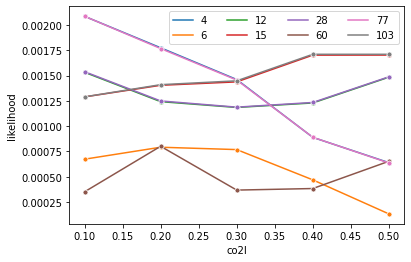

In [25]:
sns.lineplot(data=cluster_props.loc[selected_cluster].reset_index() , x='co2l', y='likelihood', hue='cluster_label', marker='.', ms=10, palette='tab10')
#plt.yscale('log')
plt.legend(ncol=4)

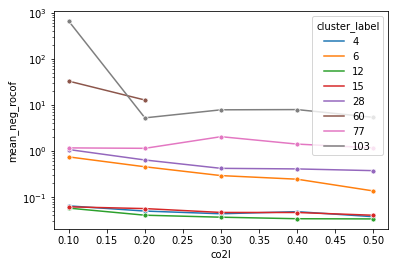

In [192]:
sns.lineplot(data=cluster_props.loc[selected_cluster].reset_index() , x='co2l', y='mean_neg_rocof', hue='cluster_label', marker='.', ms=10, palette='tab10')
plt.yscale('log')

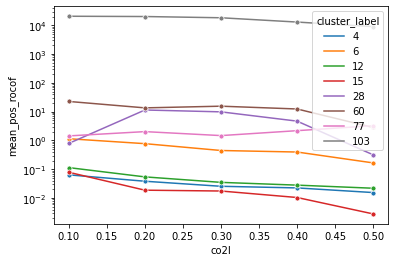

In [193]:
sns.lineplot(data=cluster_props.loc[selected_cluster].reset_index() , x='co2l', y='mean_pos_rocof', hue='cluster_label', marker='.', ms=10, palette='tab10')
plt.yscale('log')

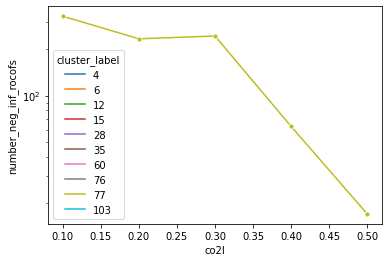

In [152]:
sns.lineplot(data=cluster_props.loc[selected_cluster].reset_index() , x='co2l', y='number_neg_inf_rocofs', hue='cluster_label', marker='.', ms=10, palette='tab10')
plt.yscale('log')

<AxesSubplot:xlabel='co2l', ylabel='rocof'>

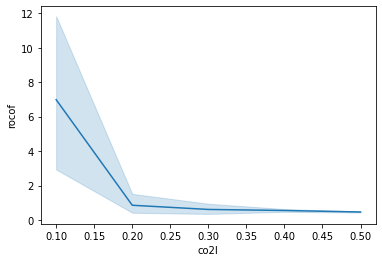

In [186]:
sns.lineplot(data=component_props[~component_props.rocof_positive] , x='co2l', y='rocof')

<AxesSubplot:xlabel='co2l', ylabel='rocof'>

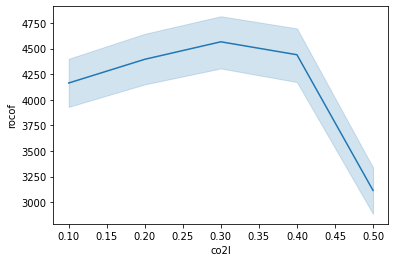

In [26]:
sns.lineplot(data=component_props[component_props.rocof_positive] , x='co2l', y='rocof')